In [327]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [328]:
df=pd.read_csv('height-weight.csv')

In [329]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Height vs Weight')

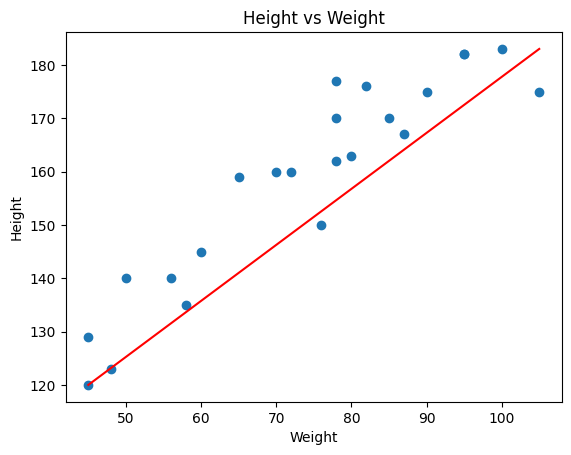

In [330]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.plot([df['Weight'].min(),df['Weight'].max()],[df['Height'].min(),df['Height'].max()],color='red')
plt.title('Height vs Weight')

In [331]:
X=df[['Weight']]
Y=df[['Height']]

In [332]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [333]:
Y

,Height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,170


In [334]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=42)

In [335]:
X.shape


(23, 1)

In [336]:
X_train.shape,X_test.shape

((16, 1), (7, 1))

In [337]:
Y_train.shape,Y_test.shape

((16, 1), (7, 1))

In [338]:
#standardize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [339]:
X_train


,Weight
13,100
5,78
2,48
11,95
20,45
3,60
4,70
18,76
16,50
21,56


In [340]:
Y_train

,Height
13,183
5,162
2,123
11,182
20,129
3,145
4,160
18,150
16,140
21,140


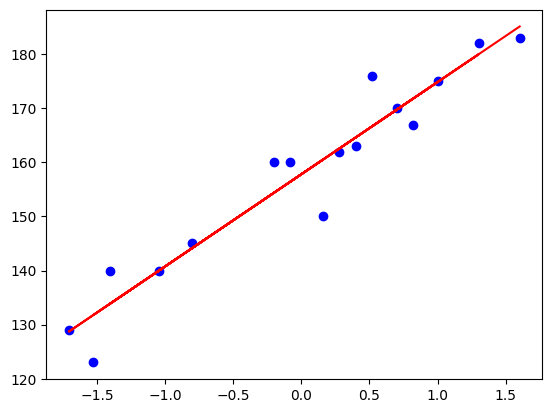

In [341]:
plt.scatter(X_train_scaled, Y_train, color='blue')
plt.plot(X_train_scaled, lr.predict(X_train_scaled), color='red')

In [342]:
#train the lr model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [343]:
print(lr.coef_)


[[17.03207732]]


In [344]:
print(lr.intercept_)

[157.8125]


1. y_pred_train=1.66386092e-17+0.94502015*X_train
2. y_pred_test=1.66386092e-17+0.94502015*X_test

In [345]:
# scaler.fit_transform(X_test_scaled,Y_test)

In [346]:
pred=lr.predict(X_test_scaled)

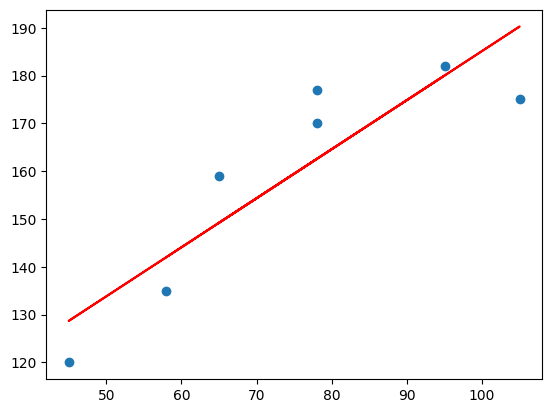

In [347]:
plt.scatter(X_test,Y_test)
plt.plot(X_test,lr.predict(X_test_scaled),'r')

In [348]:
pred,Y_test


(array([[162.55745791],
        [162.55745791],
        [128.70154204],
        [179.99838426],
        [149.22027893],
        [190.25775271],
        [142.03872102]]),
     Height
 15     177
 9      170
 0      120
 8      182
 17     159
 12     175
 1      135)

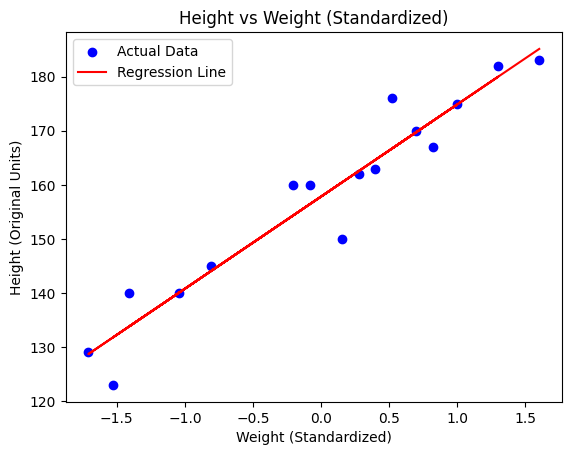

In [349]:
plt.scatter(X_train_scaled, Y_train, color='blue', label='Actual Data')

# Plot the regression line using predictions on the scaled training data
plt.plot(X_train_scaled, lr.predict(X_train_scaled), color='red', label='Regression Line')

plt.xlabel('Weight (Standardized)')
plt.ylabel('Height (Original Units)')
plt.title('Height vs Weight (Standardized)')
plt.legend()
plt.show()

In [350]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [351]:
Y_pred_test = lr.predict(X_test_scaled)

# Compare predictions to the ORIGINAL Y_test
mse = mean_squared_error(Y_test, Y_pred_test)
r2 = r2_score(Y_test, Y_pred_test)
mae=mean_absolute_error(Y_test,Y_pred_test)
adjusted_r2=1-(1-r2)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")
print(f"MAE Score: {mae}")
print(f"RMSE Score: {np.sqrt(mse)}")
print(f"adjusted R Score: {adjusted_r2}")

Mean Squared Error: 103.09818711844574
R2 Score: 0.7828485570493535
MAE Score: 9.237776679921925
RMSE Score: 10.153727744944009
adjusted R Score: 0.7394182684592242


# assummptions for a great model


In [352]:
scaled_weight=scaler.transform([[80]])
scaled_weight

c:\Users\Lenovo\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.39906064]])

In [353]:
print(lr.predict([scaled_weight[0]]))

[[164.60933159]]


In [361]:
from sklearn.metrics import r2_score
score=r2_score(Y_test,Y_pred_test)

print("r2 ", {score})

r2  {0.7828485570493535}


In [362]:
adjscore=1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)
print("adjusted r2 ",{adjscore})

adjusted r2  {0.7394182684592242}


In [363]:
scaled_wt=scaler.transform([[80]])

c:\Users\Lenovo\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [366]:
print(scaled_wt)
print(lr.predict([scaled_wt[0]]))

[[0.39906064]]
[[164.60933159]]


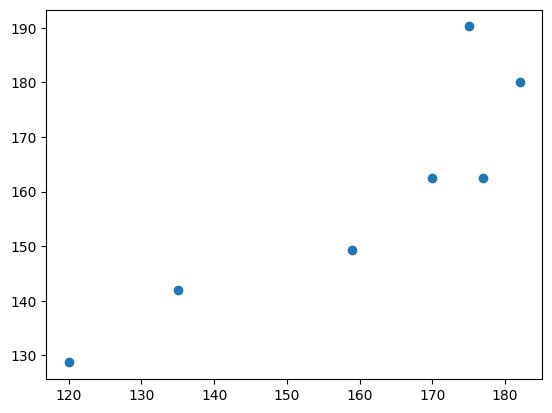

In [368]:
plt.scatter(Y_test,Y_pred_test)# a linear graph is a good prediction indicator

In [370]:
residuals=Y_test-Y_pred_test
residuals

,Height
15,14.442542
9,7.442542
0,-8.701542
8,2.001616
17,9.779721
12,-15.257753
1,-7.038721


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19376\103414424.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: ylabel='Density'>

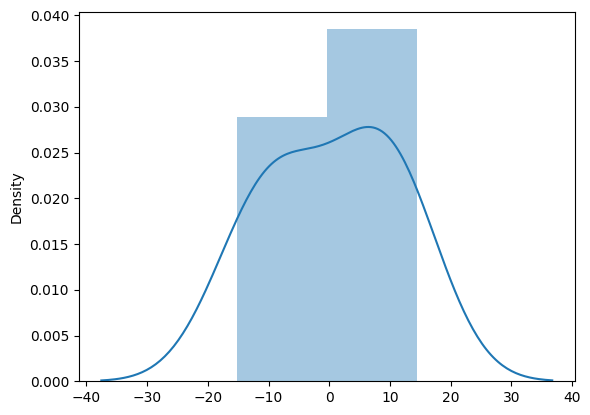

In [373]:
import seaborn as sns
sns.distplot(residuals,kde=True)
#sort of normal dist so a better model

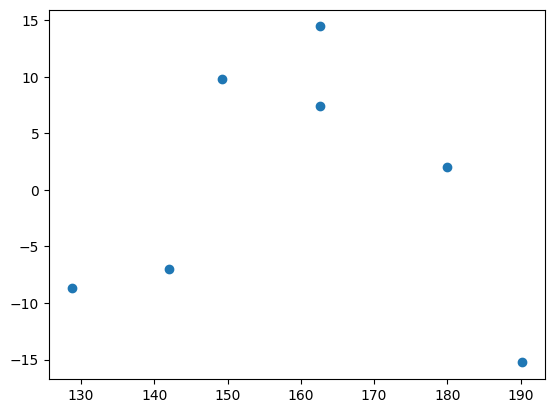

In [374]:
plt.scatter(Y_pred_test,residuals)

In [ ]:
#pickling the model later
